In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib as mpl
from pathlib import Path

In [2]:
# Definisci solo la cartella base
base_dir = Path('/Users/lorenzosisti/dopa_giugno_2026/09_07_dir/apo')

In [3]:
# ENERGY MINIMIZATION - apoDDC

# N.B. The .xvg potential energy files to be plotted must be sequentially named as open_em_rep1, open_em_rep2, closed_em_rep1, closed_em_rep2 etc...

# Empty lists to contain the data from the replicas
time_em_open = []
potential_em_open = []

time_em_closed = []
potential_em_closed = []

# Data loading
for i in [1, 2, 3]:
    
    # --- OPEN ---
    data_em_open = np.loadtxt(base_dir / f'open_em_rep{i}.xvg', comments=["@", "%", "#"]) # If the files are named differently, change here
    time_em_open.append(data_em_open[:, 0] / 1000.0)
    potential_em_open.append(data_em_open[:, 1])
    
    # --- CLOSED ---
    data_em_closed = np.loadtxt(base_dir / f'closed_em_rep{i}.xvg', comments=["@", "%", "#"]) # If the files are named differently, change here
    time_em_closed.append(data_em_closed[:, 0] / 1000.0)
    potential_em_closed.append(data_em_closed[:, 1])

FileNotFoundError: /Users/lorenzosisti/dopa_giugno_2026/09_07_dir/apo/open_em_rep1.xvg not found.

In [ ]:
# -----------------------
# FIGURA: POTENZIALE (3 rep)
# -----------------------
fig, ax = plt.subplots(figsize=(8, 4))

# Definizione colori per coerenza
colors_open = ['paleturquoise', 'deepskyblue', 'steelblue']
colors_closed = ['orchid', 'mediumvioletred', 'purple']

# --- Plotta le curve usando un ciclo ---
for i in range(3):
    ax.plot(time_em_open[i], potential_em_open[i], 
            c=colors_open[i], label=f'Open rep {i+1}', linewidth=1.0)
    
    ax.plot(time_em_closed[i], potential_em_closed[i], 
            c=colors_closed[i], label=f'Closed rep {i+1}', linewidth=1.0)

ax.set_title('Energy minimization - steepest descent', fontsize=16)

# --- Gestione limiti (automatica e pulita) ---
# Uniamo tutte le liste in un unico array per trovare min/max globali
all_vals = np.concatenate(potential_em_open + potential_em_closed)
all_times = np.concatenate(time_em_open + time_em_closed)

margin = 0.02 * (np.max(all_vals) - np.min(all_vals))
ax.set_xlim([0, np.max(all_times)])
ax.set_ylim([np.min(all_vals) - margin, np.max(all_vals) + margin])

# --- Etichette e stile ---
ax.set_xlabel('Time (ns)', fontsize=12)
ax.set_ylabel(r'Potential energy ($kJ \cdot mol^{-1}$)', fontsize=12) # LaTeX semplificato
ax.tick_params(labelsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper right', ncol=2) # ncol=2 per risparmiare spazio
ax.grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig('potential_em.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# --- RMSF ---

# Liste per i dati puliti
rmsf_open = []
rmsf_closed = []

# Caricamento e pulizia
for i in [1, 2, 3]:
    # OPEN
    data_rmsf_open = np.loadtxt(base_dir / f'rmsf_apo_open_{i}.xvg', comments=["@", "%", "#"])
    rmsf_open.append(data_rmsf_open[:, 1])
    
    # CLOSED
    data_rmsf_closed = np.loadtxt(base_dir / f'rmsf_apo_closed_{i}.xvg', comments=["@", "%", "#"])
    rmsf_closed.append(data_rmsf_closed[:, 1])

# Estraiamo l'indice dei residui solo dal primo file (è identico per tutti)
# Usiamo data_o perché è l'ultima variabile caricata nel ciclo
index = data_rmsf_open[:, 0]

FileNotFoundError: /Users/lorenzosisti/dopa_giugno_2026/09_07_dir/apo/rmsf_apo_open_1.xvg not found.

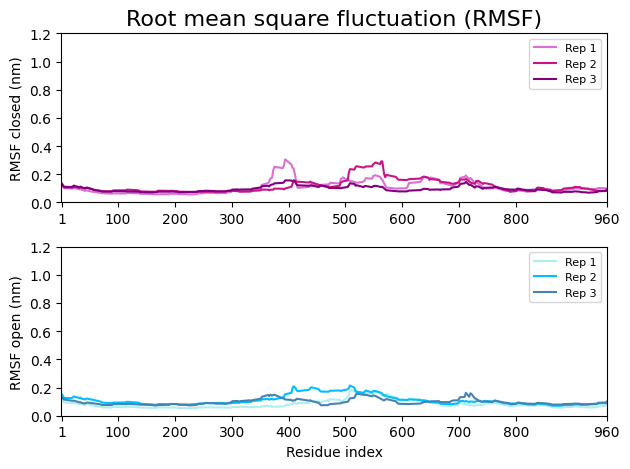

In [22]:
# ----------------------- 
# RMSF CLOSED (Subplot in alto) 
# ----------------------- 
ax2 = plt.subplot(211) 

# Usiamo l'indice della lista [0, 1, 2] invece delle variabili singole
ax2.plot(index, rmsf_closed[0], c='orchid', label="Rep 1") 
ax2.plot(index, rmsf_closed[1], c='mediumvioletred', label="Rep 2") 
ax2.plot(index, rmsf_closed[2], c='purple', label="Rep 3") 

ax2.set_title('Root mean square fluctuation (RMSF)', fontsize=16)
ax2.set_xlim([0, 960]) 
ax2.set_ylim([0, 1.2]) 
ax2.set_ylabel('RMSF closed (nm)', fontsize=10) 
ax2.set_xticks([1, 100, 200, 300, 400, 500, 600, 700, 800, 960]) 
ax2.legend(fontsize=8) 

# ----------------------- 
# RMSF OPEN (Subplot in basso) 
# ----------------------- 
ax1 = plt.subplot(212) 

ax1.plot(index, rmsf_open[0], c='paleturquoise', label="Rep 1") 
ax1.plot(index, rmsf_open[1], c='deepskyblue', label="Rep 2") 
ax1.plot(index, rmsf_open[2], c='steelblue', label="Rep 3") 

ax1.set_xlim([0, 960]) 
ax1.set_ylim([0, 1.2]) 
ax1.set_xlabel('Residue index', fontsize=10) 
ax1.set_ylabel('RMSF open (nm)', fontsize=10) 
ax1.set_xticks([1, 100, 200, 300, 400, 500, 600, 700, 800, 960]) 
ax1.legend(fontsize=8) 

plt.tight_layout() 
# plt.savefig('rmsf_combined.png', dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
# RMSF per singole catene A e B

rmsf_closed_1 = np.loadtxt(base_dir / 'rmsf_chainA.xvg', comments =["@", "%", "#"])
rmsf_closed_2 = np.loadtxt(base_dir / 'rmsf_chainB.xvg', comments =["@", "%", "#"])

index = rmsf_closed_1[:,0]

rmsf_closed_1 = rmsf_closed_1[:,1]
rmsf_closed_2 = rmsf_closed_2[:,1]

In [ ]:
# ----------------------- 
# RMSF OPEN (3 rep) 
# ----------------------- 
ax1 = plt.subplot(212) 
# --- Plotta le due curve --- 
ax1.plot(index, rmsf_closed_1, c='mediumvioletred', label="Chain A") 
ax1.plot(index, rmsf_closed_2[:478], c='deepskyblue', label="Chain B") 
#ax1.set_title(r'RMSF', fontsize=16)

# --- Impostazioni assi --- 
ax1.set_xlim([0, 478]) 
ax1.set_ylim([0, 1.05]) 
ax1.set_xlabel(r'Residue index', fontsize=10) 
ax1.set_ylabel(r'RMSF open (nm)', fontsize=10) 
ax1.set_xticks([1, 100, 200, 300, 400, 478]) 
ax1.legend(fontsize=8) 
#plt.tight_layout() 

In [17]:
# --- RMSD ---

# Liste vuote per contenere i dati delle repliche
time_rmsd_open = []
rmsd_open = []

time_rmsd_closed = []
rmsd_closed = []

# Caricamento dati
for i in [1, 2, 3]:
    
    # --- OPEN ---
    # Carica il file della replica i-esima
    data_rmsd_open = np.loadtxt(base_dir / f'rmsd_apo_open_{i}.xvg', comments=["@", "%", "#"])
    time_rmsd_open.append(data_rmsd_open[:, 0] / 1000.0) # Tempo in ns
    rmsd_open.append(data_rmsd_open[:, 1])               # Valori RMSD
    
    # --- CLOSED ---
    # Carica il file della replica i-esima
    data_rmsd_closed = np.loadtxt(base_dir / f'rmsd_apo_closed_{i}.xvg', comments=["@", "%", "#"])
    time_rmsd_closed.append(data_rmsd_closed[:, 0] / 1000.0) # Tempo in ns
    rmsd_closed.append(data_rmsd_closed[:, 1])               # Valori RMSD

/var/folders/9z/m_kyptn90sdcgsmxxq_fjnjc0000gn/T/ipykernel_13014/942421008.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


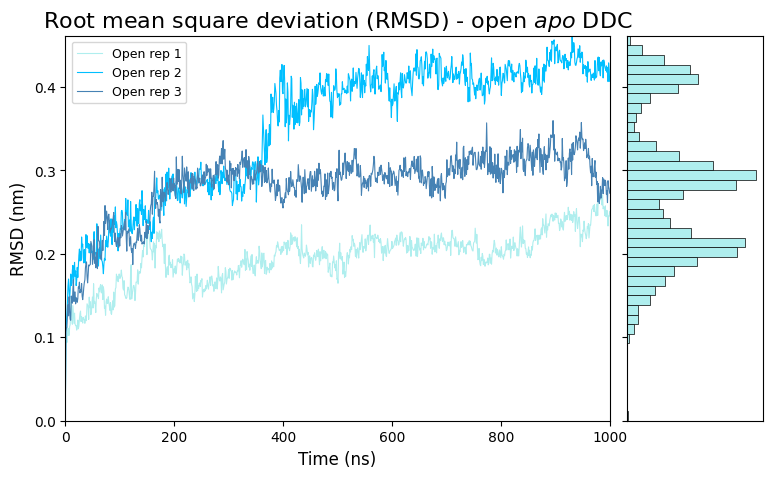

/var/folders/9z/m_kyptn90sdcgsmxxq_fjnjc0000gn/T/ipykernel_13014/942421008.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


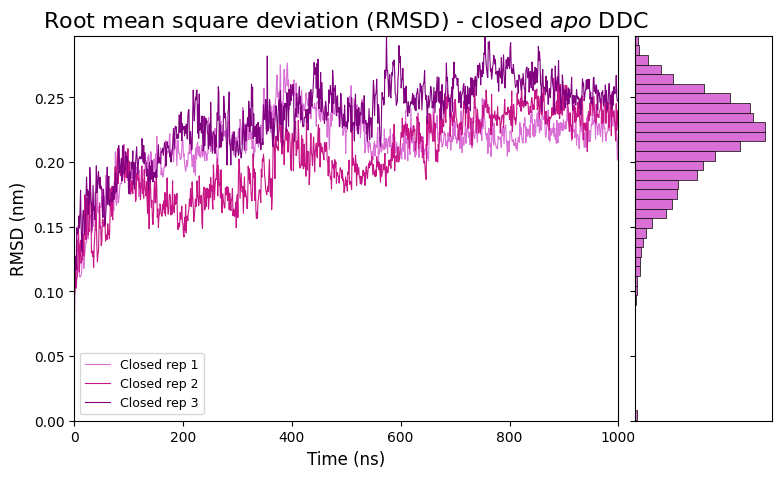

In [18]:
# -----------------------
# FIGURA 1: OPEN (3 rep)
# -----------------------
fig = plt.figure(figsize=(9, 5))
gs = fig.add_gridspec(1, 2, width_ratios=(4, 1), wspace=0.05)

ax = fig.add_subplot(gs[0, 0])
ax_histy = fig.add_subplot(gs[0, 1], sharey=ax)

# Colori per coerenza
colors_open = ['paleturquoise', 'deepskyblue', 'steelblue']

# Plot delle 3 repliche OPEN usando le nuove liste
for i in range(3):
    ax.plot(time_rmsd_open[i], rmsd_open[i], 
            linewidth=0.8, color=colors_open[i], label=f'Open rep {i+1}')

ax.set_title(r'Root mean square deviation (RMSD) - open $\mathit{apo}$ DDC', fontsize=16)
ax.set_xlim([0, 1000])

# Calcolo limite Y e Istogramma
all_open = np.concatenate(rmsd_open)
ax.set_ylim([0, max(np.max(all_open), 0.1)])

ax_histy.hist(all_open, bins=40, orientation='horizontal',
              color='paleturquoise', edgecolor='k', linewidth=0.5)

# Stile e Label
ax.set_xlabel('Time (ns)', fontsize=12)
ax.set_ylabel('RMSD (nm)', fontsize=12)
ax.legend(fontsize=9, frameon=True)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.tick_params(axis="x", labelbottom=False, bottom=False)

plt.tight_layout()
plt.savefig('rmsd_open_combined.png', dpi=300)
plt.show()

# -----------------------
# FIGURA 2: CLOSED (3 rep)
# -----------------------
fig = plt.figure(figsize=(9, 5))
gs = fig.add_gridspec(1, 2, width_ratios=(4, 1), wspace=0.05)

ax = fig.add_subplot(gs[0, 0])
ax_histy = fig.add_subplot(gs[0, 1], sharey=ax)

colors_closed = ['orchid', 'mediumvioletred', 'purple']

# Plot delle 3 repliche CLOSED usando le nuove liste
for i in range(3):
    ax.plot(time_rmsd_closed[i], rmsd_closed[i], 
            linewidth=0.8, color=colors_closed[i], label=f'Closed rep {i+1}')

ax.set_title(r'Root mean square deviation (RMSD) - closed $\mathit{apo}$ DDC', fontsize=16)
ax.set_xlim([0, 1000])

# Calcolo limite Y e Istogramma
all_closed = np.concatenate(rmsd_closed)
ax.set_ylim([0, max(np.max(all_closed), 0.1)])

ax_histy.hist(all_closed, bins=40, orientation='horizontal',
              color='orchid', edgecolor='k', linewidth=0.5)

# Stile e Label
ax.set_xlabel('Time (ns)', fontsize=12)
ax.set_ylabel('RMSD (nm)', fontsize=12)
ax.legend(fontsize=9, frameon=True)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.tick_params(axis="x", labelbottom=False, bottom=False)

plt.tight_layout()
plt.savefig('rmsd_closed_combined.png', dpi=300)
plt.show()

In [ ]:
# --- GYRATION RADIUS ---

# Liste vuote per contenere i dati
time_gyr_open = []
rg_open = []

time_gyr_closed = []
rg_closed = []

# Caricamento dati con ciclo for
for i in [1, 2, 3]:
    
    # --- OPEN ---
    data_gyr_open = np.loadtxt(base_dir / f'gyration_open_{i}.xvg', comments=["@", "%", "#"])
    time_gyr_open.append(data_gyr_open[:, 0] / 1000.0) # Tempo in ns
    rg_open.append(data_gyr_open[:, 1])                # Rg valore
    
    # --- CLOSED ---
    data_gyr_closed = np.loadtxt(base_dir / f'gyration_closed_{i}.xvg', comments=["@", "%", "#"])
    time_gyr_closed.append(data_gyr_closed[:, 0] / 1000.0) # Tempo in ns
    rg_closed.append(data_gyr_closed[:, 1])                # Rg valore

# Un vettore tempo di riferimento (preso dall'ultima replica caricata)
time_gyr = time_gyr_open[-1]

In [ ]:
# -----------------------
# FIGURA GYRATION RADIUS (Open & Closed)
# -----------------------
fig = plt.figure(figsize=(8, 8))

# Colori per coerenza
colors_open = ['paleturquoise', 'deepskyblue', 'steelblue']
colors_closed = ['orchid', 'mediumvioletred', 'purple']

# --- SUBPLOT 1: CLOSED (In alto) ---
ax2 = plt.subplot(211)
for i in range(3):
    ax2.plot(time_gyr_closed[i], rg_closed[i], 
             c=colors_closed[i], label=f'Closed rep {i+1}', linewidth=1.0)

all_closed = np.concatenate(rg_closed)
margin_c = (np.max(all_closed) - np.min(all_closed)) * 0.1
ax2.set_ylim([np.min(all_closed) - margin_c, np.max(all_closed) + margin_c])
ax2.set_xlim([0, np.max(time_gyr_closed[0])])
ax2.set_ylabel(r'$R_\mathrm{gyr}$ closed (nm)', fontsize=12)
ax2.set_title('Radius of Gyration', fontsize=16)

# --- SUBPLOT 2: OPEN (In basso) ---
ax1 = plt.subplot(212)
for i in range(3):
    ax1.plot(time_gyr_open[i], rg_open[i], 
             c=colors_open[i], label=f'Open rep {i+1}', linewidth=1.0)

all_open = np.concatenate(rg_open)
margin_o = (np.max(all_open) - np.min(all_open)) * 0.1
ax1.set_ylim([np.min(all_open) - margin_o, np.max(all_open) + margin_o])
ax1.set_xlim([0, np.max(time_gyr_open[0])])
ax1.set_ylabel(r'$R_\mathrm{gyr}$ open (nm)', fontsize=12)
ax1.set_xlabel('Time (ns)', fontsize=12)

# --- Stile comune ---
for ax in [ax1, ax2]:
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9, frameon=True, loc='upper right')
    ax.grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig('gyration_combined_3rep.png', dpi=300, bbox_inches='tight')
plt.show()